# Uniform grating coupler in BeamZ

This notebook reproduces the workflow of Flexcompute's
[Tidy3D uniform grating coupler example](https://www.flexcompute.com/tidy3d/examples/notebooks/GratingCoupler/)
using BeamZ geometry, sources, monitors, mode solving, and local execution.

The workflow stays deliberately close to the reference:

1. construct and inspect an SOI grating;
2. estimate its period from unetched and etched slab modes;
3. sweep period and fiber position and plot coupling efficiency;
4. construct a finite-width 3D grating with a taper; and
5. plot its wavelength-dependent fiber-to-waveguide coupling.

BeamZ's tilted `GaussianBeamSource` is currently a 3D source. The fast design-loop
model therefore uses a two-cell-wide 3D strip with PEC sidewalls, which is the
native TE-equivalent of the reference notebook's y-periodic 2D model. The final
model is fully 3D.


In [1]:
import gc
import os

import matplotlib.pyplot as plt
import numpy as np
try:
    from IPython.display import display
except ImportError:
    display = print

import beamz as bz
from beamz.analysis import mode_data_to_dataframe

test_mode = os.environ.get("BEAMZ_DOCS_TEST") == "1"
execution_backend = "jax" if test_mode else "cuda_streamed"

um = bz.um

## Latest spatial-resolution convergence result

The final 3D model was repeated without changing its physical geometry, source,
monitor, frequencies, or run time. Only the uniform grid spacing was refined.
Both additional runs used the direct `cuda_streamed` backend.

| Silicon points per wavelength | Grid cells | Coupling at 1.55 µm | Loss | Spectral peak |
|---:|---:|---:|---:|---:|
| 8 | 22.45 M | 25.59% | −5.92 dB | — |
| 10 | 44.08 M | 37.66% | −4.24 dB | 38.80% at 1.543 µm |
| 12 | 75.84 M | 38.64% | −4.13 dB | 39.35% at 1.545 µm |

The large 8→10 correction confirms substantial staircasing/numerical loss on the
coarse grid. The much smaller 10→12 change (0.11 dB at 1.55 µm) indicates that
the spectrum is beginning to converge, although this is not a formal asymptotic
convergence study. The measured high-resolution spectra are retained below so the
comparison plot does not require rerunning either expensive simulation.


In [2]:
wavelengths_convergence = np.linspace(1.50, 1.60, 101)
coupling_10ppw = np.array([0.09204473, 0.09796710, 0.10415794, 0.11063074, 0.11739347, 0.12445246, 0.13180947, 0.13945658, 0.14738759, 0.15558390, 0.16402347, 0.17267904, 0.18151877, 0.19050457, 0.19960626, 0.20878544, 0.21800444, 0.22722168, 0.23641738, 0.24556151, 0.25462017, 0.26357389, 0.27239990, 0.28108761, 0.28961374, 0.29796404, 0.30611307, 0.31405642, 0.32176970, 0.32921750, 0.33637788, 0.34322155, 0.34971160, 0.35580753, 0.36147467, 0.36667390, 0.37136661, 0.37551420, 0.37909892, 0.38209406, 0.38448324, 0.38625914, 0.38741989, 0.38797735, 0.38794092, 0.38733155, 0.38617474, 0.38449822, 0.38232736, 0.37969211, 0.37662321, 0.37314582, 0.36928630, 0.36506844, 0.36051203, 0.35563423, 0.35045340, 0.34498686, 0.33924931, 0.33325145, 0.32701766, 0.32056124, 0.31389823, 0.30705103, 0.30004736, 0.29290516, 0.28564577, 0.27830294, 0.27090120, 0.26345720, 0.25600480, 0.24856939, 0.24116297, 0.23380819, 0.22652750, 0.21933602, 0.21224365, 0.20526300, 0.19840517, 0.19167918, 0.18508963, 0.17864811, 0.17235487, 0.16621848, 0.16024033, 0.15442358, 0.14877136, 0.14328606, 0.13796829, 0.13282117, 0.12784042, 0.12303290, 0.11839304, 0.11391980, 0.10961344, 0.10547142, 0.10148989, 0.09766795, 0.09399905, 0.09048180, 0.08710974])
coupling_12ppw = np.array([0.08376757, 0.08940470, 0.09532199, 0.10153770, 0.10806298, 0.11490329, 0.12206662, 0.12954895, 0.13734917, 0.14545506, 0.15384489, 0.16249990, 0.17139098, 0.18048300, 0.18974937, 0.19914623, 0.20863460, 0.21816834, 0.22772070, 0.23725342, 0.24672532, 0.25611288, 0.26539085, 0.27453873, 0.28352752, 0.29234372, 0.30097236, 0.30939242, 0.31757793, 0.32550595, 0.33315227, 0.34049023, 0.34747732, 0.35408452, 0.36028845, 0.36604095, 0.37130761, 0.37606122, 0.38028454, 0.38394420, 0.38701410, 0.38949803, 0.39138944, 0.39268664, 0.39339266, 0.39353105, 0.39312594, 0.39218756, 0.39073823, 0.38881522, 0.38644322, 0.38363223, 0.38040955, 0.37679955, 0.37281629, 0.36846489, 0.36376952, 0.35874759, 0.35340487, 0.34775474, 0.34182428, 0.33563138, 0.32918561, 0.32251445, 0.31564515, 0.30859832, 0.30139404, 0.29406675, 0.28664223, 0.27914247, 0.27159957, 0.26403883, 0.25648608, 0.24896200, 0.24148620, 0.23408227, 0.22676697, 0.21954557, 0.21242839, 0.20543454, 0.19856022, 0.19181378, 0.18520410, 0.17873941, 0.17241888, 0.16625379, 0.16024813, 0.15440471, 0.14872845, 0.14322556, 0.13788888, 0.13272536, 0.12773054, 0.12290282, 0.11824156, 0.11374559, 0.10941337, 0.10524198, 0.10123065, 0.09737898, 0.09368189])


## 1. Initial design

We target 1.50–1.60 µm on an SOI stack. As in the reference notebook, silicon and
silica are treated as nondispersive over this narrow band. The 260 nm silicon
layer is etched by 160 nm, leaving a 100 nm slab. The uniform grating has 20 teeth
and an 80% silicon fill fraction.


In [3]:
lambda0 = 1.55 * um
freq0 = bz.LIGHT_SPEED / lambda0
wavelengths = np.linspace(1.50, 1.60, 3 if test_mode else 101) * um
freqs = bz.LIGHT_SPEED / wavelengths
fwidth = 0.5 * (np.max(freqs) - np.min(freqs))

n_si = 3.47
n_sio2 = 1.44
mat_air = bz.Material(permittivity=1.0)
mat_si = bz.Material(permittivity=n_si**2)
mat_sio2 = bz.Material(permittivity=n_sio2**2)

t_si = 0.26 * um
etch_depth = 0.16 * um
fill_fraction = 0.80
t_top_oxide = 0.68 * um
t_box = 2.0 * um
num_teeth = 4 if test_mode else 20

theta = np.deg2rad(14.5)
mode_field_diameter = 10.8 * um
buffer = 0.60 * lambda0
source_gap = 0.50 * um
source_time = bz.GaussianPulse(freq0=freq0, fwidth=fwidth, offset=0.5 if test_mode else 4.0)
mode_spec = bz.ModeSpec(num_modes=1, target_neff=n_si, polarization="te")

print(f"Silicon slab remaining after etch: {(t_si - etch_depth) / um:.2f} µm")


Silicon slab remaining after etch: 0.10 µm


### Geometry helpers

The objects are added in painter's order: oxide and substrate first, the residual
silicon slab second, and the teeth last. Each tooth restores the full 260 nm
silicon thickness over its filled part of the period.


In [4]:
def box_from_bounds(lower, upper, material):
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    return bz.Box(
        center=tuple(0.5 * (lower + upper)),
        size=tuple(upper - lower),
        material=material,
    )


def add_vertical_stack(design, bounds, *, z_offset=0.0):
    x_min, x_max, y_min, y_max, z_min, z_max = bounds
    design += box_from_bounds(
        (x_min, y_min, z_offset),
        (x_max, y_max, z_offset + t_top_oxide),
        mat_sio2,
    )
    design += box_from_bounds(
        (x_min, y_min, z_offset - t_box),
        (x_max, y_max, z_offset),
        mat_sio2,
    )
    design += box_from_bounds(
        (x_min, y_min, z_min),
        (x_max, y_max, z_offset - t_box),
        mat_si,
    )
    return design


def add_grating_teeth(
    design, period, y_min, y_max, *, x_offset=0.0, z_offset=0.0
):
    for index in range(num_teeth):
        x0 = x_offset + index * period
        x1 = x0 + fill_fraction * period
        design += box_from_bounds(
            (x0, y_min, z_offset + t_si - etch_depth),
            (x1, y_max, z_offset + t_si),
            mat_si,
        )
    return design


### Parameterized design-loop simulation

The source is a 1 W Gaussian beam tilted by 14.5° toward −x and polarized along
y. A mode monitor on the input slab measures the power coupled into the
fundamental mode travelling toward −x. In BeamZ, `angle_phi=np.pi` selects that negative-x tangential wavevector for a `-z` beam.

API opportunity: native 2D `GaussianBeamSource` support plus periodic boundaries
would remove the thin-strip equivalence used here and make this stage as compact
as the Tidy3D `make_2d_sim` function.


In [5]:
def make_design_loop_sim(period, source_x):
    grating_length = num_teeth * period
    steps_per_wavelength = 4 if test_mode else 25
    resolution = lambda0 / (steps_per_wavelength * n_si)
    # Keep at least two y cells: GaussianBeamSource is a 3D TF/SF source.
    strip_width = max(2.1 * resolution, 0.12 * um)

    reference_lower = np.array(
        (-buffer, -0.5 * strip_width, -t_box - buffer), dtype=float
    )
    reference_upper = np.array(
        (grating_length + buffer, 0.5 * strip_width, t_si + t_top_oxide + buffer),
        dtype=float,
    )
    # BeamZ domains are centered at the origin. Translate every geometry,
    # source, and monitor coordinate together; Tidy3D expresses this as
    # Simulation(center=sim_box.center, size=sim_box.size).
    shift = -0.5 * (reference_lower + reference_upper)
    lower = reference_lower + shift
    upper = reference_upper + shift
    x_min, y_min, z_min = lower
    x_max, y_max, z_max = upper
    x0, _, z0 = shift

    design = add_vertical_stack(
        bz.Design(background=mat_air),
        (x_min, x_max, y_min, y_max, z_min, z_max),
        z_offset=z0,
    )
    # Unetched input slab (reference x < 0).
    design += box_from_bounds(
        (x_min, y_min, z0), (x0, y_max, z0 + t_si), mat_si
    )
    # Residual 100 nm slab beneath the grating (reference x > 0).
    design += box_from_bounds(
        (x0, y_min, z0),
        (x_max, y_max, z0 + t_si - etch_depth),
        mat_si,
    )
    design = add_grating_teeth(
        design, period, y_min, y_max, x_offset=x0, z_offset=z0
    )

    pml_thickness = 12 * resolution
    source_half_width = min(
        mode_field_diameter,
        source_x - reference_lower[0] - pml_thickness,
        reference_upper[0] - pml_thickness - source_x,
    )
    source = bz.GaussianBeamSource(
        center=(source_x + x0, 0.0, t_top_oxide + source_gap + z0),
        size=(2 * source_half_width, strip_width, 0.0),
        source_time=source_time,
        direction="-z",
        angle_theta=theta,
        angle_phi=np.pi,
        pol_angle=np.pi / 2,
        waist_radius=0.5 * mode_field_diameter,
        background_index=1.0,
        wavelength=lambda0,
        power=1.0,
    )
    monitor = bz.ModeMonitor(
        center=(reference_lower[0] + pml_thickness + 2 * resolution + x0, 0.0, 0.5 * t_si + z0),
        size=(0.0, strip_width, 6 * t_si),
        freqs=freqs,
        mode_spec=mode_spec,
        name="mode",
    )
    simulation = bz.Simulation(
        domain=tuple(reference_upper - reference_lower),
        design=design,
        sources=(source,),
        monitors=(monitor,),
        boundaries=(bz.PML(formulation="cpml"),),
        grid_spec=bz.GridSpec.uniform(resolution),
        run_time=(8.0 / freq0) if test_mode else 2.0e-12,
    )
    return simulation, {
        "source": source,
        "monitor": monitor,
        "bounds": (x_min, x_max, y_min, y_max, z_min, z_max),
        "shift": shift,
    }


Design-loop grid: (664, 7, 269) | time steps: 58711


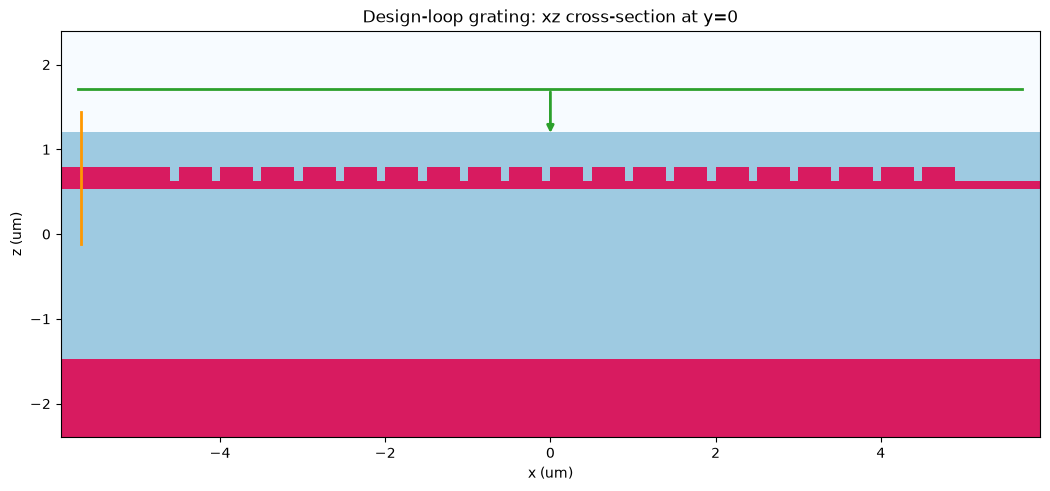

In [6]:
sim0, preview = make_design_loop_sim(
    period=0.50 * um, source_x=(1.2 if test_mode else 5.0) * um
)
print(f"Design-loop grid: {sim0.grid.shape} | time steps: {sim0.num_steps}")

# sim.plot() returns the standard xy/xz pair. The thin-strip xy view is not
# informative, so retain the reference notebook's single xz setup view.
fig, axes = sim0.plot(
    y=0.0,
    z=t_si - 0.5 * etch_depth,
    figsize=(10.5, 4.8),
    width_ratios=(0.001, 1.0),
    source_markers=True,
    monitor_markers=True,
    show=False,
)
axes = np.asarray(axes).flat
axes[0].set_visible(False)
axes[1].grid(False)
axes[1].set_title("Design-loop grating: xz cross-section at y=0")
plt.show()


## 2. Estimate the grating period from slab modes

For first-order coupling,

$$
\Lambda = \frac{\lambda_0}
{n_{\mathrm{eff}} - n_{\mathrm{clad}}\sin\theta_{\mathrm{clad}}},
\qquad
n_{\mathrm{eff}} \approx f n_{\mathrm{unetched}} + (1-f)n_{\mathrm{etched}}.
$$

Like `ModeSimulation.from_simulation` in the reference, the two BeamZ
`ModeSource.solve_modes` calls reuse the exact simulation geometry and grid but
move the solve plane to an unetched and an etched cross-section. These objects
are solve requests only; they are not attached as FDTD sources.


In [7]:
shift_2d = np.asarray(preview["shift"])
unetched_probe = bz.ModeSource(
    center=(-0.10 * um + shift_2d[0], 0.0, 0.5 * t_si + shift_2d[2]),
    size=(0.0, sim0.design.height, 5 * t_si),
    source_time=source_time,
    direction="-",
    mode_spec=mode_spec,
)
etched_probe = unetched_probe.updated_copy(
    center=(
        num_teeth * 0.50 * um + 0.10 * um + shift_2d[0],
        0.0,
        0.5 * t_si + shift_2d[2],
    )
)

unetched_modes = unetched_probe.solve_modes(sim0, freqs=[freq0])
etched_modes = etched_probe.solve_modes(sim0, freqs=[freq0])
display(mode_data_to_dataframe(unetched_modes))
display(mode_data_to_dataframe(etched_modes))


,,wavelength,n eff,k eff,loss (dB/cm),mode area
f,mode_index,,,,,
1.934145e+14,0,1.55,2.954398,0.0,0.0,0.039351


,,wavelength,n eff,k eff,loss (dB/cm),mode area
f,mode_index,,,,,
1.934145e+14,0,1.55,2.188442,0.0,0.0,0.040381


In [8]:
neff_unetched = float(np.real(np.asarray(unetched_modes.neffs)[0, 0]))
neff_etched = float(np.real(np.asarray(etched_modes.neffs)[0, 0]))

# Snell's law converts the 14.5° air angle to the angle inside the oxide.
theta_cladding = np.arcsin(np.sin(theta) / n_sio2)
weighted_neff = (
    fill_fraction * neff_unetched + (1 - fill_fraction) * neff_etched
)
estimated_period = lambda0 / (
    weighted_neff - n_sio2 * np.sin(theta_cladding)
)

print(f"n_eff unetched = {neff_unetched:.4f}")
print(f"n_eff etched   = {neff_etched:.4f}")
print(f"Estimated grating period = {estimated_period / bz.nm:.0f} nm")


n_eff unetched = 2.9544
n_eff etched   = 2.1884
Estimated grating period = 608 nm


## 3. Sweep period and fiber position

To keep local execution practical, the sweep samples 3 periods × 3 source
positions, for 9 simulations total. This preserves the reference workflow's two
design variables while bounding the runtime. BeamZ executes locally, so the
dictionary of immutable simulations is followed by an explicit loop rather than
a cloud batch.

API opportunity: a public local `Batch` helper with bounded concurrency, progress,
result persistence, and automatic compiled-cache eviction would make parameter
sweeps substantially less verbose.


In [9]:
periods = np.linspace(0.600, 0.630, 1 if test_mode else 3) * um
source_positions = (
    np.array([1.2]) if test_mode else np.linspace(3.0, 5.0, 3)
) * um

simulations_2d = {
    f"p={period / um:.4f};source_x={source_x / um:.4f}": make_design_loop_sim(
        period, source_x
    )[0]
    for period in periods
    for source_x in source_positions
}
print(f"Prepared {len(simulations_2d)} immutable design-loop simulations.")


Prepared 9 immutable design-loop simulations.


In [10]:
sweep_results = {}
for index, (name, simulation) in enumerate(simulations_2d.items(), start=1):
    print(f"[{index:02d}/{len(simulations_2d):02d}] {name}")
    sweep_results[name] = simulation.run(
        progress=False,
        backend=execution_backend,
        performance=False,
    )
    # Each period realizes a slightly different domain shape. Evict compiled
    # plans as we go so a local sweep does not retain every device allocation.
    simulation.clear_compiled_cache()
    gc.collect()


[01/09] p=0.6000;source_x=3.0000


[02/09] p=0.6000;source_x=4.0000


[03/09] p=0.6000;source_x=5.0000


[04/09] p=0.6150;source_x=3.0000


[05/09] p=0.6150;source_x=4.0000


[06/09] p=0.6150;source_x=5.0000


[07/09] p=0.6300;source_x=3.0000


[08/09] p=0.6300;source_x=4.0000


[09/09] p=0.6300;source_x=5.0000


In [11]:
coupling_efficiency = np.empty((len(periods), len(source_positions)))
for i, period in enumerate(periods):
    for j, source_x in enumerate(source_positions):
        name = f"p={period / um:.4f};source_x={source_x / um:.4f}"
        mode_data = sweep_results[name].mode("mode")
        amplitude = (
            mode_data.amps.sel(direction="-", mode_index=0)
            .sel(f=freq0, method="nearest")
            .item()
        )
        coupling_efficiency[i, j] = np.abs(amplitude) ** 2

best_index = np.unravel_index(
    np.nanargmax(coupling_efficiency), coupling_efficiency.shape
)
best_period = periods[best_index[0]]
best_source_x = source_positions[best_index[1]]
best_efficiency = coupling_efficiency[best_index]


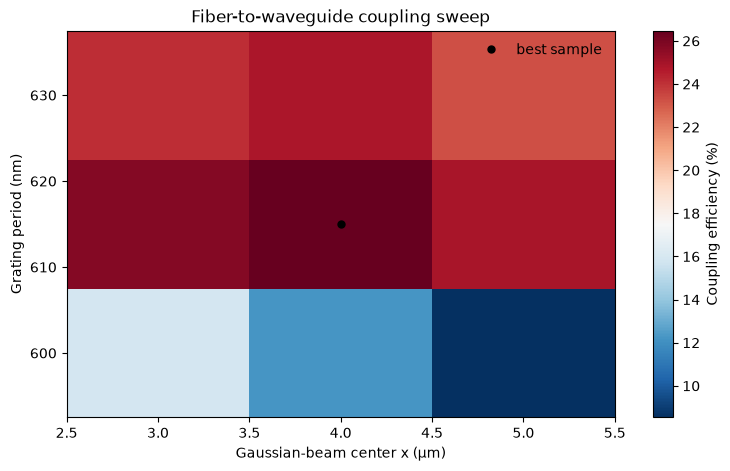

Optimal period = 615.0 nm
Optimal source x = 4.00 µm
Optimal coupling = 26.47% (-5.77 dB)


21

In [12]:
fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)
mesh = ax.pcolormesh(
    source_positions / um,
    periods / bz.nm,
    100 * coupling_efficiency,
    shading="auto",
    cmap="RdBu_r",
)
colorbar = fig.colorbar(mesh, ax=ax)
colorbar.set_label("Coupling efficiency (%)")
ax.plot(best_source_x / um, best_period / bz.nm, "ko", ms=5, label="best sample")
ax.set(
    title="Fiber-to-waveguide coupling sweep",
    xlabel="Gaussian-beam center x (µm)",
    ylabel="Grating period (nm)",
)
ax.grid(False)
ax.legend(frameon=False)
plt.show()

print(f"Optimal period = {best_period / bz.nm:.1f} nm")
print(f"Optimal source x = {best_source_x / um:.2f} µm")
print(
    f"Optimal coupling = {100 * best_efficiency:.2f}% "
    f"({10 * np.log10(max(best_efficiency, 1e-15)):.2f} dB)"
)

# The 12-points/λ 3D grid is large. Release every design-loop result and
# compiled plan before rasterizing it so notebook execution stays within
# the host-memory budget. The compact sweep arrays and selected optimum remain.
sim0.clear_compiled_cache()
for simulation in simulations_2d.values():
    simulation.clear_compiled_cache()
del sweep_results, simulations_2d, mode_data
del unetched_modes, etched_modes, sim0, preview
plt.close('all')
gc.collect()


## 4. Three-dimensional grating coupler

This is the same finite-width geometry as the Tidy3D reference: a 10.8 µm-wide
grating connected to a 500 nm waveguide by a 50 µm linear taper. The mode monitor
is halfway through the straight output buffer, exactly as in the reference.

Tidy3D's `GridSpec.auto(min_steps_per_wvl=15)` is a nonuniform material-aware
mesh. BeamZ currently offers a uniform grid here; using 15 steps per silicon
wavelength everywhere would create about 149 million cells and is not safe on a
local 24 GB GPU. The BeamZ run therefore uses 8 uniform steps per silicon
wavelength with subpixel material averaging. This changes numerical resolution,
not device geometry. A future nonuniform-grid API would remove this compromise.


In [13]:
waveguide_width = 0.50 * um
grating_width = mode_field_diameter
taper_length = (5.0 if test_mode else 50.0) * um


def make_3d_sim(period, source_x):
    grating_length = num_teeth * period
    reference_lower = np.array(
        (-buffer - taper_length, -0.5 * grating_width - buffer, -t_box - buffer),
        dtype=float,
    )
    reference_upper = np.array(
        (grating_length + buffer, 0.5 * grating_width + buffer, t_si + t_top_oxide + buffer),
        dtype=float,
    )
    shift = -0.5 * (reference_lower + reference_upper)
    lower = reference_lower + shift
    upper = reference_upper + shift
    x_min, y_min, z_min = lower
    x_max, y_max, z_max = upper
    x0, _, z0 = shift  # reference coordinates x=0 and z=0 after translation
    bounds = (x_min, x_max, y_min, y_max, z_min, z_max)

    design = add_vertical_stack(
        bz.Design(background=mat_air), bounds, z_offset=z0
    )
    # Residual etched slab across the grating region, matching the reference.
    design += box_from_bounds(
        (x0, y_min, z0),
        (x_max, y_max, z0 + t_si - etch_depth),
        mat_si,
    )
    design = add_grating_teeth(
        design,
        period,
        -0.5 * grating_width,
        0.5 * grating_width,
        x_offset=x0,
        z_offset=z0,
    )

    # Exact six-vertex Tidy3D taper, including its straight output extension.
    taper_vertices = (
        (x0, 0.5 * grating_width),
        (x0, -0.5 * grating_width),
        (x0 - taper_length, -0.5 * waveguide_width),
        (x0 - taper_length - 2 * buffer, -0.5 * waveguide_width),
        (x0 - taper_length - 2 * buffer, 0.5 * waveguide_width),
        (x0 - taper_length, 0.5 * waveguide_width),
    )
    design += bz.Polygon(
        vertices=taper_vertices,
        depth=t_si,
        z=z0,
        material=mat_si,
    )

    steps_per_wavelength = 4 if test_mode else 12
    resolution = lambda0 / (steps_per_wavelength * n_si)
    source = bz.GaussianBeamSource(
        center=(source_x + x0, 0.0, t_top_oxide + source_gap + z0),
        size=(2 * mode_field_diameter, 2 * mode_field_diameter, 0.0),
        source_time=source_time,
        direction="-z",
        angle_theta=theta,
        angle_phi=np.pi,
        pol_angle=np.pi / 2,
        waist_radius=0.5 * mode_field_diameter,
        background_index=1.0,
        wavelength=lambda0,
        power=1.0,
    )
    monitor = bz.ModeMonitor(
        center=(x0 - taper_length - 0.5 * buffer, 0.0, 0.5 * t_si + z0),
        size=(0.0, 4 * waveguide_width, 6 * t_si),
        freqs=freqs,
        mode_spec=mode_spec,
        name="mode",
    )
    domain = reference_upper - reference_lower
    field_xz = bz.FieldMonitor(
        center=(0.0, 0.0, 0.0),
        size=(domain[0], 0.0, domain[2]),
        freqs=[freq0],
        fields=("Ex", "Ey", "Ez"),
        name="field_xz",
    )
    simulation = bz.Simulation(
        domain=tuple(domain),
        design=design,
        sources=(source,),
        monitors=(monitor, field_xz),
        boundaries=(bz.PML(formulation="cpml"),),
        grid_spec=bz.GridSpec.uniform(
            resolution,
            max_total_cells=100_000_000,
        ),
        run_time=(8.0 / freq0) if test_mode else 2.0e-12,
    )
    return simulation, {
        "source": source,
        "monitor": monitor,
        "field_xz": field_xz,
        "bounds": bounds,
        "shift": shift,
    }


3D grid: (1724, 341, 129) = 75.84 M cells
Time steps: 28182
Gaussian-beam propagation direction: k_hat = (-0.2504, +0.0000, -0.9681)


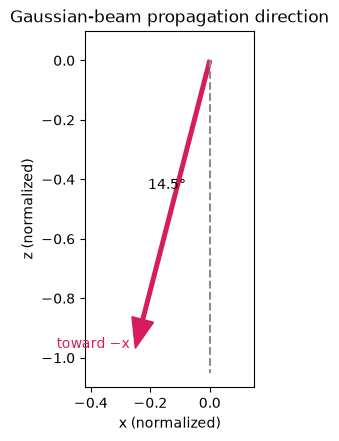

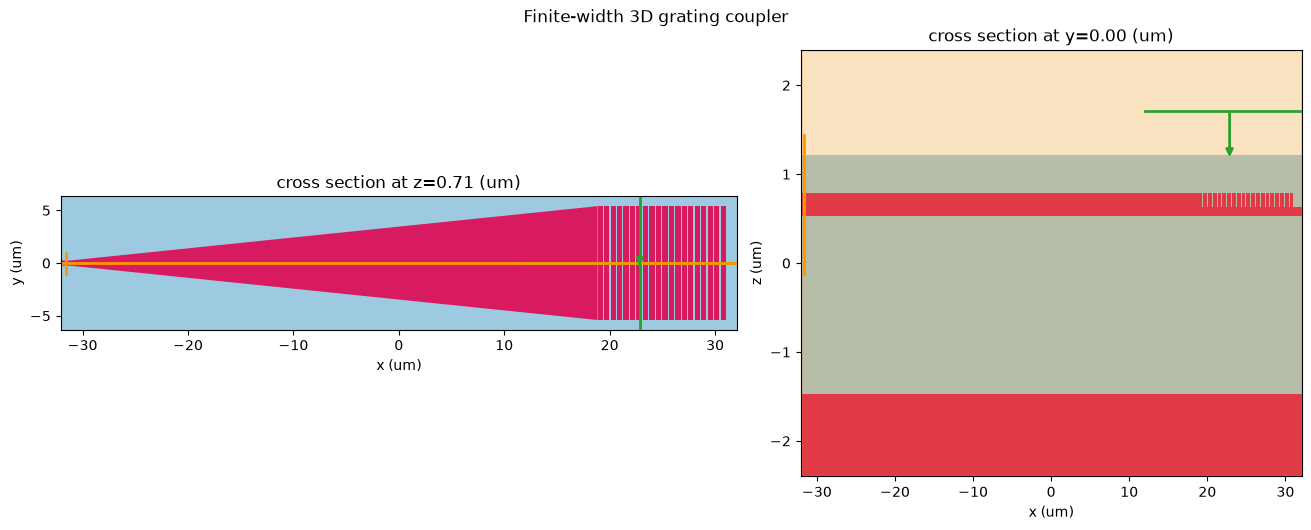

In [14]:
sim_3d, setup_3d = make_3d_sim(best_period, best_source_x)
cell_count = int(np.prod(sim_3d.grid.shape))
print(f"3D grid: {sim_3d.grid.shape} = {cell_count / 1e6:.2f} M cells")
print(f"Time steps: {sim_3d.num_steps}")

# BeamZ uses x and y as the transverse axes of a z-normal source plane.
# For direction=-z and phi=pi, the tangential wavevector points toward -x.
beam_direction = np.array(
    (-np.sin(theta), 0.0, -np.cos(theta)), dtype=float
)
print(
    "Gaussian-beam propagation direction: "
    f"k_hat = ({beam_direction[0]:+.4f}, {beam_direction[1]:+.4f}, "
    f"{beam_direction[2]:+.4f})"
)

fig, ax = plt.subplots(figsize=(4.3, 4.3), constrained_layout=True)
ax.plot((0.0, 0.0), (0.0, -1.05), color="0.55", ls="--", lw=1.5)
ax.arrow(
    0.0,
    0.0,
    beam_direction[0],
    beam_direction[2],
    width=0.012,
    head_width=0.075,
    head_length=0.10,
    length_includes_head=True,
    color="#d81b60",
)
ax.text(-0.08, -0.42, f"{np.rad2deg(theta):.1f}°", ha="right", va="center")
ax.text(-0.27, -0.93, "toward −x", ha="right", va="top", color="#d81b60")
ax.set(
    title="Gaussian-beam propagation direction",
    xlabel="x (normalized)",
    ylabel="z (normalized)",
    xlim=(-0.42, 0.15),
    ylim=(-1.10, 0.10),
)
ax.set_aspect("equal")
ax.grid(False)
plt.show()

fig, axes = sim_3d.plot(
    z=setup_3d["shift"][2] + t_si - 0.5 * etch_depth,
    y=0.0,
    figsize=(13, 5.0),
    width_ratios=(1.35, 1.0),
    source_markers=True,
    monitor_markers=True,
    show=False,
)
for axis in np.asarray(axes).flat:
    axis.grid(False)
fig.suptitle("Finite-width 3D grating coupler", y=1.03)
plt.show()


In [15]:
results_3d = sim_3d.run(
    progress=True,
    backend="cuda_streamed",
    performance=True,
)

* Compiling simulation...

* Running simulation: [--------------------] 0% (0/28182 steps)

* Running simulation: [#-------------------] 5% (1410/28182 steps)

* Running simulation: [##------------------] 10% (2820/28182 steps)

* Running simulation: [###-----------------] 15% (4230/28182 steps)

...

* Running simulation: [#################---] 85% (23970/28182 steps)

* Running simulation: [##################--] 90% (25380/28182 steps)

* Running simulation: [###################-] 95% (26790/28182 steps)

* Running simulation: [####################] 100% (28182/28182 steps)

Simulation runtime: 380.36 s
GCUPS: 5.619


## 5. Field propagation at 1.55 µm

The center-frequency DFT field on the symmetry plane provides a direct visual
check of the source convention. The real $E_y$ close-up shows wavefronts descending
toward −x onto the grating. The electric-field magnitude then shows the coupled
field propagating left through the 50 µm taper. Material boundaries are overlaid
by BeamZ's public field-plotting helper; grid lines remain disabled.

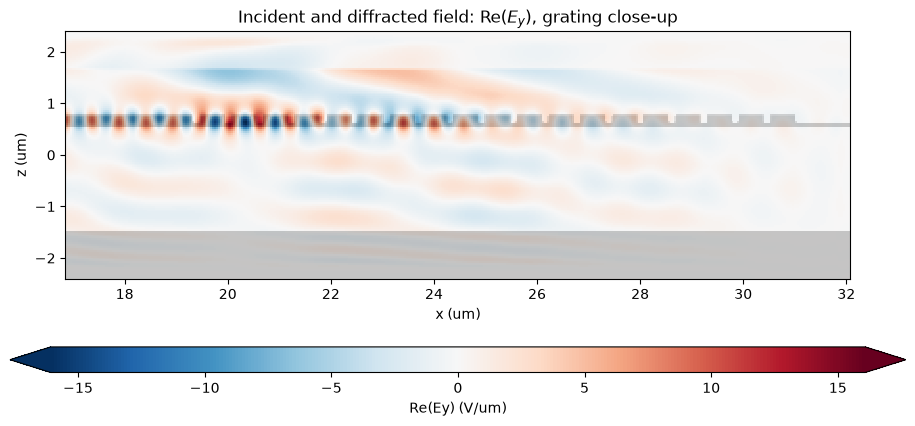

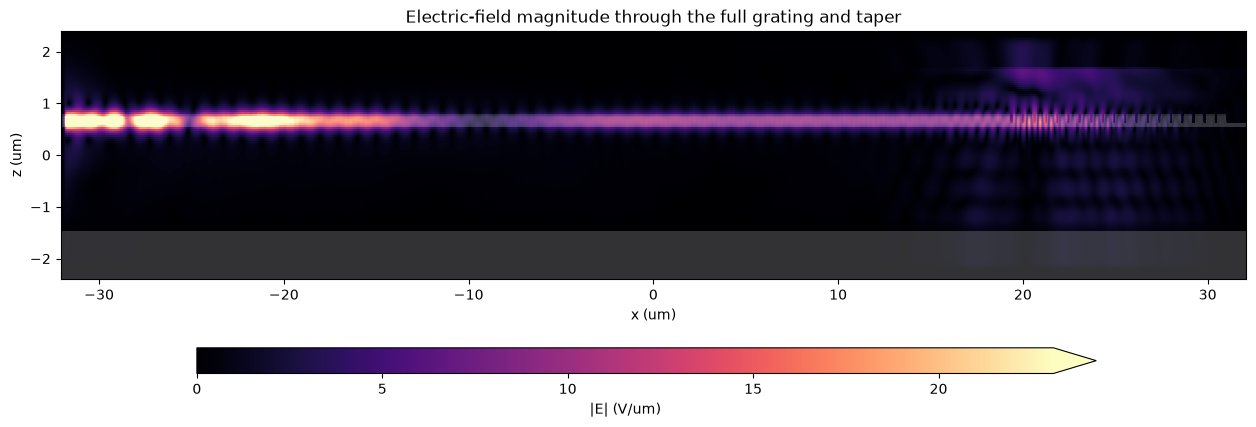

In [16]:
x0_3d = setup_3d["shift"][0]
grating_length_3d = num_teeth * best_period
grating_xlim = (
    (x0_3d - 2.0 * um) / um,
    (x0_3d + grating_length_3d + buffer) / um,
)
domain_x_um = sim_3d.domain[0] / um

fig, ax = results_3d.plot_field(
    monitor_name="field_xz",
    field_name="Ey",
    frequency=freq0,
    val="real",
    cmap="RdBu_r",
    xlim=grating_xlim,
    figsize=(12.5, 4.2),
    show=False,
)
ax.set_title("Incident and diffracted field: Re($E_y$), grating close-up")
ax.grid(False)
plt.show()

fig, ax = results_3d.plot_field(
    monitor_name="field_xz",
    field_name="E",
    frequency=freq0,
    val="abs",
    cmap="magma",
    xlim=(-0.5 * domain_x_um, 0.5 * domain_x_um),
    figsize=(12.5, 4.0),
    show=False,
)
ax.set_title("Electric-field magnitude through the full grating and taper")
ax.set_aspect("auto")
ax.grid(False)
plt.show()


## 6. Coupling spectrum

The mode monitor reports source-normalized complex amplitudes. Because the
Gaussian beam requests 1 W, the squared magnitude of the backward fundamental
mode amplitude is the fiber-to-waveguide coupling efficiency.


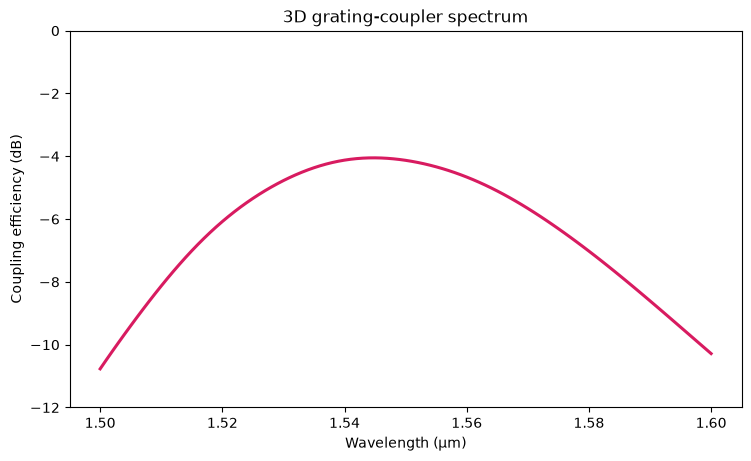

Coupling at 1.550 µm: 38.64% (-4.13 dB)


In [17]:
mode_3d = results_3d.mode("mode")
amplitude_3d = np.asarray(mode_3d.amps.sel(direction="-", mode_index=0))
coupling_3d = np.abs(amplitude_3d) ** 2
assert np.all(np.isfinite(coupling_3d))

fig, ax = plt.subplots(figsize=(7.4, 4.5), constrained_layout=True)
ax.plot(
    wavelengths / um,
    10 * np.log10(np.maximum(coupling_3d, 1e-15)),
    color="#d81b60",
    lw=2.2,
)
ax.set(
    title="3D grating-coupler spectrum",
    xlabel="Wavelength (µm)",
    ylabel="Coupling efficiency (dB)",
    ylim=(-12, 0),
)
ax.grid(False)
plt.show()

center_index = int(np.argmin(np.abs(wavelengths - lambda0)))
print(
    f"Coupling at {wavelengths[center_index] / um:.3f} µm: "
    f"{100 * coupling_3d[center_index]:.2f}% "
    f"({10 * np.log10(max(coupling_3d[center_index], 1e-15)):.2f} dB)"
)


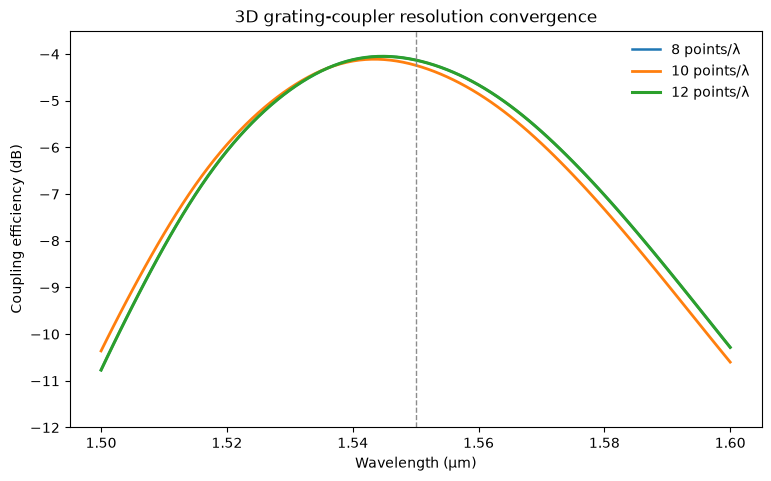

In [18]:
fig, ax = plt.subplots(figsize=(7.6, 4.7), constrained_layout=True)
ax.plot(wavelengths / um, 10 * np.log10(np.maximum(coupling_3d, 1e-15)), lw=1.8, label='8 points/λ')
ax.plot(wavelengths_convergence, 10 * np.log10(coupling_10ppw), lw=2.0, label='10 points/λ')
ax.plot(wavelengths_convergence, 10 * np.log10(coupling_12ppw), lw=2.2, label='12 points/λ')
ax.axvline(1.55, color='0.55', ls='--', lw=1.0)
ax.set(title='3D grating-coupler resolution convergence', xlabel='Wavelength (µm)', ylabel='Coupling efficiency (dB)', ylim=(-12, -3.5))
ax.grid(False)
ax.legend(frameon=False)
plt.show()
